Install required packages

In [1]:
!pip install shap lime statsmodels matplotlib fpdf seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 9.0 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ff826e1a61c6bfb29df9f49d689a7e2effc4982fa21de4d4f0fa6365c03c6be3
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=c78585096231f890f5a10eae5e72943e18fa2b3fd631b224bb80fe031e234eaf
  Stored in directory: /root/.cache/pip/wheels/f9/95/ba/f418094659025eb9611f17cbcaf2334236bf39a0c3453ea455
Successfully built lime fpdf


Import necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor
import shap
from fpdf import FPDF

Create sample time series data

In [4]:
np.random.seed(42)
date_range = pd.date_range(start='2010-01-01', periods=120, freq='ME')
data = np.random.randn(120).cumsum() + 50

df = pd.DataFrame(data, columns=['sales'], index=date_range)

Plotting Time Series

In [5]:
def plot_time_series(data, title="Time Series Data"):
    plt.figure(figsize=(10, 5))
    plt.plot(data.index, data.values, label='Sales', color='b')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Values')
    plt.grid(True)
    plt.legend()
    plt.savefig('timeseries_plot.png')
    plt.show()

Stationarity Tests

In [6]:
def stationarity_tests(data):
    # KPSS Test
    kpss_stat, kpss_p, _, _ = kpss(data)
    # Dickey-Fuller Test
    adf_stat, adf_p, *_ = adfuller(data)

    print(f"KPSS Test: p-value = {kpss_p}")
    print(f"Dickey-Fuller Test: p-value = {adf_p}")
    return kpss_p, adf_p

ACF and PACF plots

In [7]:
def plot_acf_pacf(data):
    fig, ax = plt.subplots(1, 2, figsize=(16, 4))
    plot_acf(data, lags=20, ax=ax[0], title="Autocorrelation Function (ACF)")
    plot_pacf(data, lags=20, ax=ax[1], title="Partial Autocorrelation Function (PACF)")
    plt.savefig('acf_pacf_plot.png')
    plt.show()

Seasonal Decomposition of Time Series (Trend, Seasonality, Residuals)

In [8]:
def seasonal_decomposition(data):
    decomposition = seasonal_decompose(data, model='additive')
    fig = decomposition.plot()
    plt.savefig('seasonal_decomposition.png')
    plt.show()

Residual Plot

In [10]:
def plot_residuals(data, model_result):
    residuals = model_result.resid
    plt.figure(figsize=(10, 5))
    plt.plot(data.index, residuals, label='Residuals', color='r')
    plt.title('Residuals of SARIMA Model')
    plt.xlabel('Date')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.legend()
    plt.savefig('residual_plot.png')
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, kde=True, color='purple')
    plt.title('Residual Distribution')
    plt.grid(True)
    plt.savefig('residual_distribution.png')
    plt.show()

Time Series Model: SARIMA


In [11]:
def fit_sarima(data):
    model = sm.tsa.SARIMAX(data, order=(1,1,1), seasonal_order=(1,1,1,12))
    result = model.fit()
    forecast = result.forecast(steps=24)

    plt.figure(figsize=(10, 5))
    plt.plot(data.index, data.values, label='Observed')
    plt.plot(pd.date_range(data.index[-1], periods=24, freq='M'), forecast, label='Forecast', color='green')
    plt.title('SARIMA Model Forecast')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True)
    plt.savefig('sarima_forecast.png')
    plt.show()

    return result

Explainable AI using SHAP for Feature Importance

In [12]:
def explain_model(model, data):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(data)

    # Plot SHAP Summary
    shap.summary_plot(shap_values, data, show=False)
    plt.savefig('shap_summary.png')
    plt.show()

Generating PDF Report

In [19]:
# 8. Generating PDF Report
def create_pdf_report():
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()

    # Title
    pdf.set_font("Arial", "B", 16)
    pdf.cell(200, 10, txt="Time Series Analysis Report", ln=True, align='C')

    # 1. Time Series Plot
    pdf.set_font("Arial", size=12)
    pdf.cell(200, 10, txt="1. Time Series Plot", ln=True, align='L')
    pdf.image('timeseries_plot.png', x=10, y=30, w=180)

    # Ensure sufficient space and add new page for next plot
    pdf.ln(95)
    pdf.add_page()

    # 2. ACF and PACF Plot
    pdf.cell(200, 10, txt="2. ACF and PACF Plot", ln=True, align='L')
    pdf.image('acf_pacf_plot.png', x=10, y=30, w=180)

    pdf.ln(95)
    pdf.add_page()

    # 3. SARIMA Forecast
    pdf.cell(200, 10, txt="3. SARIMA Forecast", ln=True, align='L')
    pdf.image('sarima_forecast.png', x=10, y=30, w=180)

    pdf.ln(95)
    pdf.add_page()

    # 4. Residual Plot
    pdf.cell(200, 10, txt="4. Residual Plot", ln=True, align='L')
    pdf.image('residual_plot.png', x=10, y=30, w=180)

    pdf.ln(95)
    pdf.add_page()

    # 5. Residual Distribution
    pdf.cell(200, 10, txt="5. Residual Distribution", ln=True, align='L')
    pdf.image('residual_distribution.png', x=10, y=30, w=180)

    pdf.ln(95)
    pdf.add_page()

    # 6. SHAP Summary Plot
    pdf.cell(200, 10, txt="6. SHAP Summary Plot", ln=True, align='L')
    pdf.image('shap_summary.png', x=10, y=30, w=180)

    # Finally, add a new page for the seasonal decomposition
    pdf.add_page()
    pdf.cell(200, 10, txt="7. Seasonal Decomposition", ln=True, align='L')
    pdf.image('seasonal_decomposition.png', x=10, y=30, w=180)

    # Save PDF to file
    pdf.output("time_series_report_exai.pdf")


Main workflow

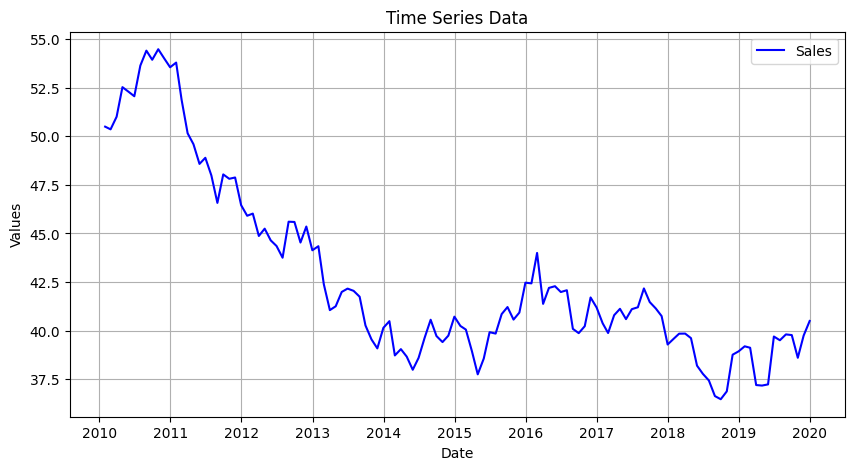

<ipython-input-6-872d532ea8b7>:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(data)


KPSS Test: p-value = 0.01
Dickey-Fuller Test: p-value = 0.2531448351769763


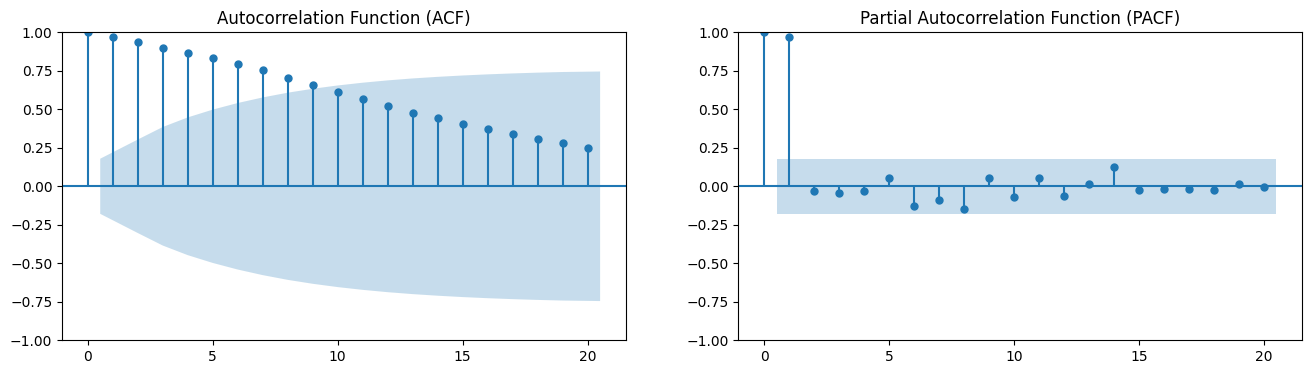

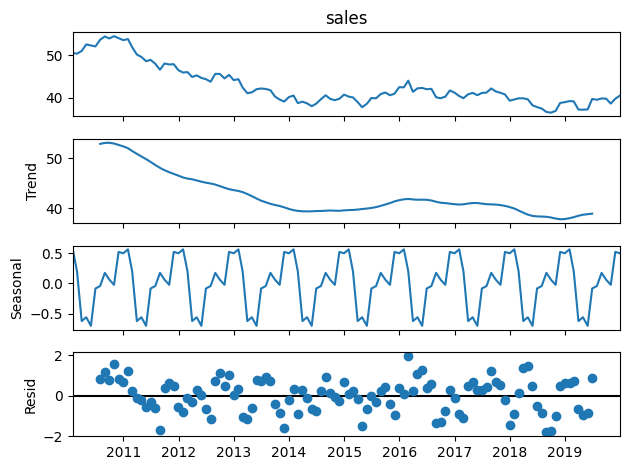

<ipython-input-11-5300c6bd6471>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(data.index[-1], periods=24, freq='M'), forecast, label='Forecast', color='green')


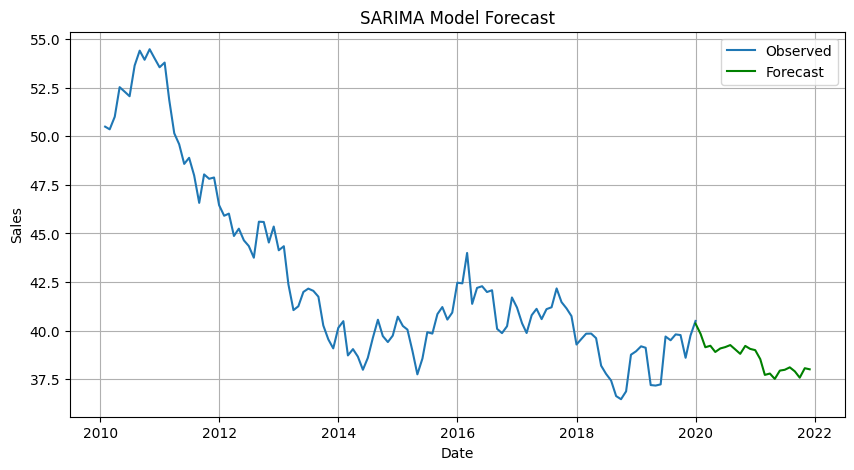

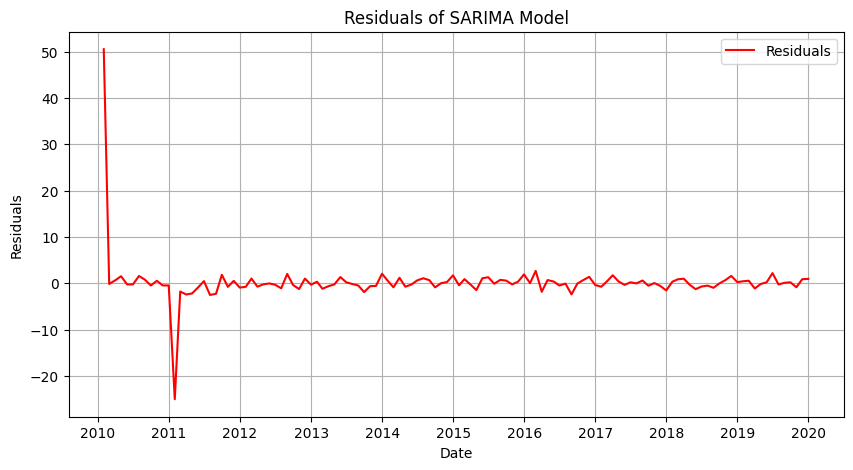

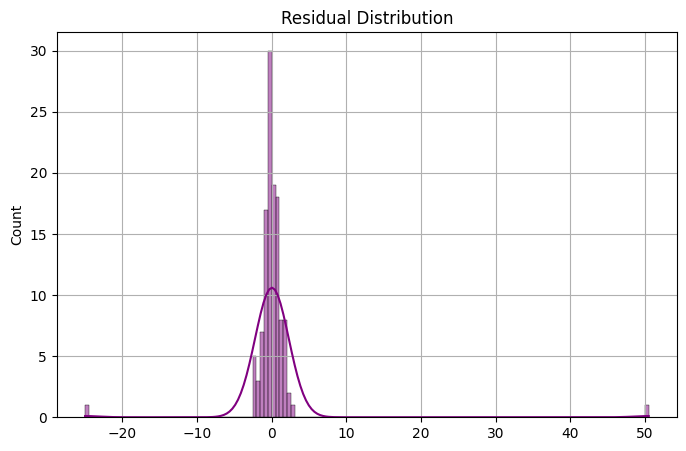

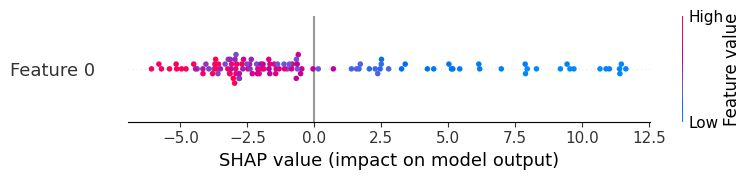

In [20]:
plot_time_series(df)
stationarity_tests(df['sales'])
plot_acf_pacf(df['sales'])
seasonal_decomposition(df['sales'])
sarima_result = fit_sarima(df['sales'])
plot_residuals(df['sales'], sarima_result)

# Random Forest Model for SHAP
X = np.arange(len(df)).reshape(-1, 1)
y = df['sales'].values
rf_model = RandomForestRegressor().fit(X, y)
explain_model(rf_model, X)

# Create the PDF report
create_pdf_report()